In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("UpdatedResumeDataSet.csv")

print("Shape:", df.shape)

df.head()

Shape: (962, 2)


,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [3]:
print(df.columns.tolist())

['Category', 'Resume']


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 962 entries, 0 to 961
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  962 non-null    object
 1   Resume    962 non-null    object
dtypes: object(2)
memory usage: 15.2+ KB
None


In [5]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [6]:
print("Total Categories:")

print(df["Category"].nunique())

print("\nCategories:\n")

print(df["Category"].unique())

Total Categories:
25

Categories:

['Data Science' 'HR' 'Advocate' 'Arts' 'Web Designing'
 'Mechanical Engineer' 'Sales' 'Health and fitness' 'Civil Engineer'
 'Java Developer' 'Business Analyst' 'SAP Developer' 'Automation Testing'
 'Electrical Engineering' 'Operations Manager' 'Python Developer'
 'DevOps Engineer' 'Network Security Engineer' 'PMO' 'Database' 'Hadoop'
 'ETL Developer' 'DotNet Developer' 'Blockchain' 'Testing']


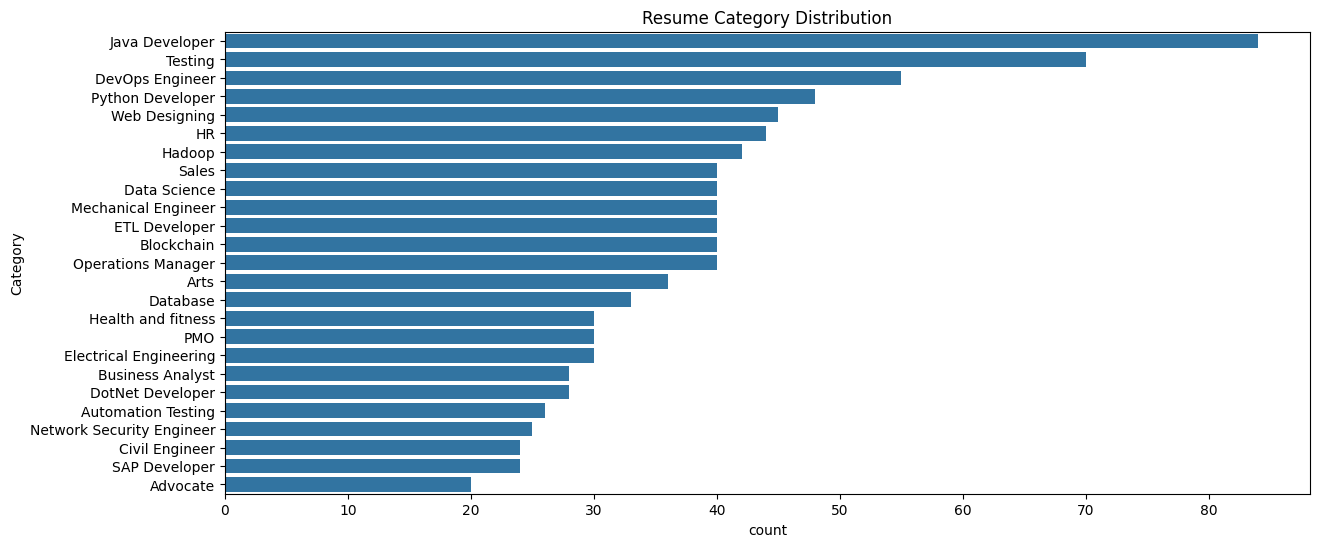

In [7]:
plt.figure(figsize=(14,6))

sns.countplot(
    y=df["Category"],
    order=df["Category"].value_counts().index
)

plt.title("Resume Category Distribution")

plt.show()

In [8]:
df["Resume_Length"] = df["Resume"].apply(len)

df["Resume_Length"].describe()

count      962.000000
mean      3160.364865
std       2886.528521
min        142.000000
25%       1217.250000
50%       2355.000000
75%       4073.750000
max      14816.000000
Name: Resume_Length, dtype: float64

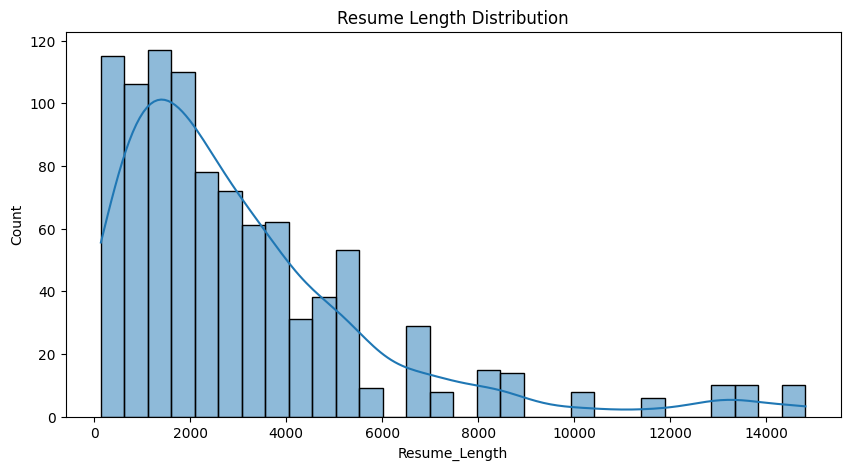

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Resume_Length"],
    bins=30,
    kde=True
)

plt.title("Resume Length Distribution")

plt.show()

In [10]:
def clean_text(text):

    text = str(text)

    text = re.sub(r"http\S+", " ", text)

    text = re.sub(r"www\S+", " ", text)

    text = re.sub(r"[^a-zA-Z ]", " ", text)

    text = text.lower()

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [11]:
df["Clean_Resume"] = df["Resume"].apply(
    clean_text
)

df.head()

,Category,Resume,Resume_Length,Clean_Resume
0,Data Science,Skills * Programming Languages: Python (pandas...,4786,skills programming languages python pandas num...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,1268,education details may to may b e uit rgpv data...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",1871,areas of interest deep learning control system...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,6995,skills r python sap hana tableau sap hana sql ...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",452,education details mca ymcaust faridabad haryan...


In [12]:
df.to_csv(
    "processed_resume_dataset.csv",
    index=False
)

print("Dataset processed successfully")

Dataset processed successfully


In [13]:
skills_db = [

    "python",
    "r",
    "sql",

    "excel",
    "tableau",
    "power bi",

    "machine learning",
    "deep learning",
    "artificial intelligence",
    "nlp",

    "tensorflow",
    "keras",
    "pytorch",

    "aws",
    "azure",
    "gcp",

    "docker",
    "kubernetes",

    "spark",
    "hadoop",

    "java",
    "c",
    "c++",

    "javascript",
    "html",
    "css",

    "react",
    "nodejs",

    "mongodb",
    "mysql",
    "postgresql",

    "git",
    "linux"
]

In [14]:
def extract_skills(text):

    text = text.lower()

    found = []

    for skill in skills_db:

        if skill in text:

            found.append(skill)

    return list(set(found))

In [15]:
df["Skills"] = df["Clean_Resume"].apply(
    extract_skills
)

df[["Category","Skills"]].head()

,Category,Skills
0,Data Science,"[c, deep learning, html, mysql, python, sql, d..."
1,Data Science,"[c, python, aws, r, keras, git, machine learning]"
2,Data Science,"[c, deep learning, mysql, python, sql, r, linu..."
3,Data Science,"[c, deep learning, python, sql, r, nlp, git, m..."
4,Data Science,"[r, java, c, python]"


In [16]:
skill_frequency = {}

for skills in df["Skills"]:

    for skill in skills:

        skill_frequency[skill] = (
            skill_frequency.get(skill,0)
            + 1
        )

In [17]:
skill_df = pd.DataFrame(

    skill_frequency.items(),

    columns=[
        "Skill",
        "Count"
    ]

)

skill_df = skill_df.sort_values(

    by="Count",

    ascending=False

)

skill_df.head(20)

,Skill,Count
0,c,962
7,r,962
5,sql,402
12,java,327
2,html,244
3,mysql,225
17,excel,216
4,python,176
11,css,154
9,javascript,151


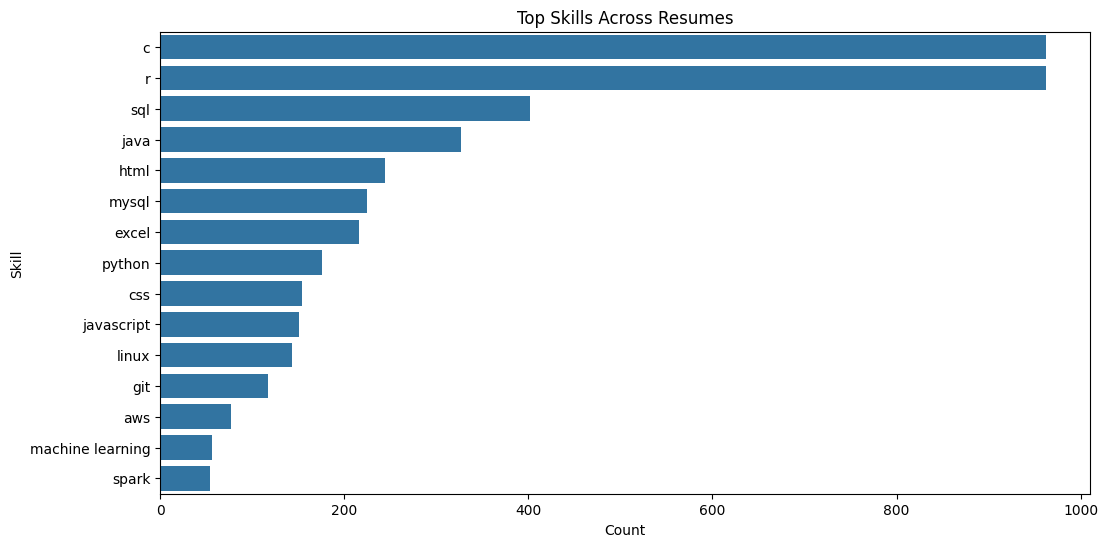

In [18]:
plt.figure(figsize=(12,6))

sns.barplot(

    data=skill_df.head(15),

    x="Count",

    y="Skill"

)

plt.title("Top Skills Across Resumes")

plt.show()

In [19]:
from wordcloud import WordCloud

In [20]:
all_text = " ".join(
    df["Clean_Resume"]
)

wordcloud = WordCloud(

    width=1200,
    height=600,

    background_color="white"

).generate(all_text)

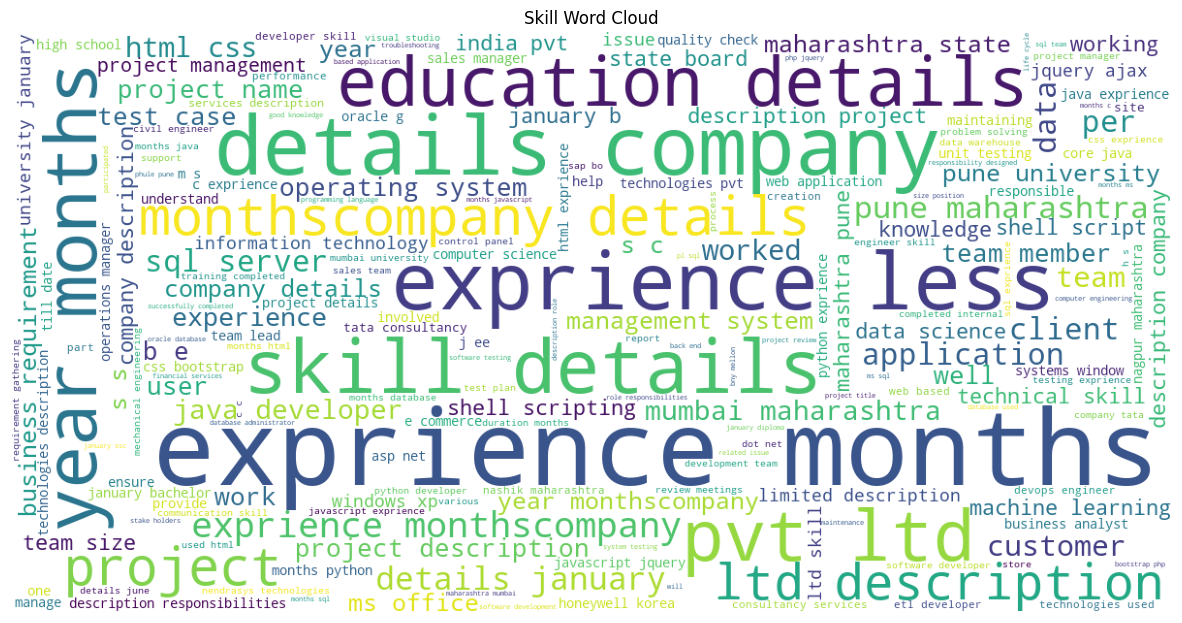

In [21]:
plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Skill Word Cloud")

plt.show()

In [22]:
education_keywords = [

    "b.tech",
    "m.tech",

    "b.e",
    "m.e",

    "b.sc",
    "m.sc",

    "bca",
    "mca",

    "mba",

    "phd",

    "bachelor",
    "master"

]

In [23]:
def extract_education(text):

    text = text.lower()

    education = []

    for degree in education_keywords:

        if degree in text:

            education.append(degree)

    return list(set(education))

In [24]:
df["Education"] = df["Resume"].apply(
    extract_education
)

df["Education"].head()

0            []
1         [b.e]
2      [b.tech]
3    [bachelor]
4         [mca]
Name: Education, dtype: object

In [25]:
def extract_experience(text):

    text = text.lower()

    patterns = [

        r'(\d+)\s+years',

        r'(\d+)\+ years',

        r'(\d+)\s+yrs',

        r'(\d+)\+ yrs'

    ]

    experience = []

    for pattern in patterns:

        matches = re.findall(
            pattern,
            text
        )

        experience.extend(matches)

    return experience

In [26]:
df["Experience"] = df["Resume"].apply(
    extract_experience
)

df["Experience"].head()

0    []
1    []
2    []
3    []
4    []
Name: Experience, dtype: object

In [27]:
certification_keywords = [

    "aws certified",

    "azure certified",

    "google certified",

    "oracle certified",

    "salesforce certified",

    "ccna",

    "pmp"

]

In [28]:
def extract_certifications(text):

    text = text.lower()

    certs = []

    for cert in certification_keywords:

        if cert in text:

            certs.append(cert)

    return certs

In [29]:
df["Certifications"] = df["Resume"].apply(
    extract_certifications
)

df["Certifications"].head()

0    []
1    []
2    []
3    []
4    []
Name: Certifications, dtype: object

In [30]:
project_keywords = [

    "project",

    "developed",

    "implemented",

    "built",

    "created"

]

In [31]:
def extract_projects(text):

    text = text.lower()

    projects = []

    for keyword in project_keywords:

        if keyword in text:

            projects.append(keyword)

    return list(set(projects))

In [32]:
df["Projects"] = df["Resume"].apply(
    extract_projects
)

df["Projects"].head()

0                 [built, developed, created, project]
1                             [developed, implemented]
2                                                   []
3    [developed, created, built, project, implemented]
4                                                   []
Name: Projects, dtype: object

In [33]:
df[[
    "Category",
    "Skills",
    "Education",
    "Experience",
    "Certifications",
    "Projects"
]].head()

,Category,Skills,Education,Experience,Certifications,Projects
0,Data Science,"[c, deep learning, html, mysql, python, sql, d...",[],[],[],"[built, developed, created, project]"
1,Data Science,"[c, python, aws, r, keras, git, machine learning]",[b.e],[],[],"[developed, implemented]"
2,Data Science,"[c, deep learning, mysql, python, sql, r, linu...",[b.tech],[],[],[]
3,Data Science,"[c, deep learning, python, sql, r, nlp, git, m...",[bachelor],[],[],"[developed, created, built, project, implemented]"
4,Data Science,"[r, java, c, python]",[mca],[],[],[]


In [34]:
df.to_csv(
    "resume_information_extracted.csv",
    index=False
)

print(
    "Information extraction completed"
)

Information extraction completed


In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics.pairwise import cosine_similarity

In [37]:
tfidf = TfidfVectorizer(

    stop_words="english",

    max_features=5000

)

resume_vectors = tfidf.fit_transform(
    df["Clean_Resume"]
)

print(resume_vectors.shape)

(962, 5000)


In [38]:
job_description = """

Looking for a Data Scientist

Skills Required:

Python
Machine Learning
Deep Learning
SQL
TensorFlow
Data Analysis

Experience:

2+ years

"""

In [39]:
jd_vector = tfidf.transform(
    [job_description]
)

In [40]:
similarity_scores = cosine_similarity(

    jd_vector,

    resume_vectors

)[0]

In [41]:
df["Similarity_Score"] = similarity_scores

df[[
    "Category",
    "Similarity_Score"
]].head()

,Category,Similarity_Score
0,Data Science,0.125171
1,Data Science,0.181108
2,Data Science,0.204860
3,Data Science,0.121189
4,Data Science,0.113033


In [42]:
top_candidates = df.sort_values(

    by="Similarity_Score",

    ascending=False

).head(10)

top_candidates[[
    "Category",
    "Similarity_Score"
]]

,Category,Similarity_Score
37,Data Science,0.378284
27,Data Science,0.378284
7,Data Science,0.378284
17,Data Science,0.378284
18,Data Science,0.326893
28,Data Science,0.326893
38,Data Science,0.326893
8,Data Science,0.326893
16,Data Science,0.305464
36,Data Science,0.305464


In [43]:
top_candidates.reset_index(
    drop=True,
    inplace=True
)

top_candidates.index += 1

top_candidates[[
    "Category",
    "Similarity_Score"
]]

,Category,Similarity_Score
1,Data Science,0.378284
2,Data Science,0.378284
3,Data Science,0.378284
4,Data Science,0.378284
5,Data Science,0.326893
6,Data Science,0.326893
7,Data Science,0.326893
8,Data Science,0.326893
9,Data Science,0.305464
10,Data Science,0.305464


In [44]:
jd_skills = extract_skills(
    job_description
)

jd_skills

['c', 'deep learning', 'python', 'sql', 'r', 'machine learning', 'tensorflow']

In [45]:
def calculate_skill_match(

    resume_skills,

    jd_skills

):

    if len(jd_skills) == 0:

        return 0

    matched = len(

        set(resume_skills)

        &

        set(jd_skills)

    )

    return (

        matched

        /

        len(jd_skills)

    ) * 100

In [46]:
df["Skill_Match_Percentage"] = df["Skills"].apply(

    lambda x:

    calculate_skill_match(

        x,

        jd_skills

    )
)

In [47]:
required_experience = 2

In [48]:
def experience_match(

    experience_list

):

    if len(experience_list) == 0:

        return 0

    years = max(

        [int(x)

         for x in experience_list]

    )

    return min(

        years

        /

        required_experience,

        1

    ) * 100

In [49]:
df["Experience_Match_Percentage"] = (

    df["Experience"]

    .apply(experience_match)

)

In [50]:
def project_match(projects):

    if len(projects) > 0:

        return 100

    return 0

In [51]:
df["Project_Match_Percentage"] = (

    df["Projects"]

    .apply(project_match)

)

In [52]:
df["Final_Score"] = (

      0.5 * df["Similarity_Score"] * 100

    + 0.3 * df["Skill_Match_Percentage"]

    + 0.1 * df["Experience_Match_Percentage"]

    + 0.1 * df["Project_Match_Percentage"]

)

In [53]:
ranked_candidates = df.sort_values(

    by="Final_Score",

    ascending=False

)

In [54]:
top10 = ranked_candidates.head(10)

top10[[
    "Category",

    "Skill_Match_Percentage",

    "Experience_Match_Percentage",

    "Project_Match_Percentage",

    "Final_Score"
]]

,Category,Skill_Match_Percentage,Experience_Match_Percentage,Project_Match_Percentage,Final_Score
37,Data Science,100.000000,100.0,100,68.914207
17,Data Science,100.000000,100.0,100,68.914207
27,Data Science,100.000000,100.0,100,68.914207
7,Data Science,100.000000,100.0,100,68.914207
36,Data Science,57.142857,50.0,100,47.416059
16,Data Science,57.142857,50.0,100,47.416059
26,Data Science,57.142857,50.0,100,47.416059
6,Data Science,57.142857,50.0,100,47.416059
18,Data Science,85.714286,0.0,0,42.058950
28,Data Science,85.714286,0.0,0,42.058950


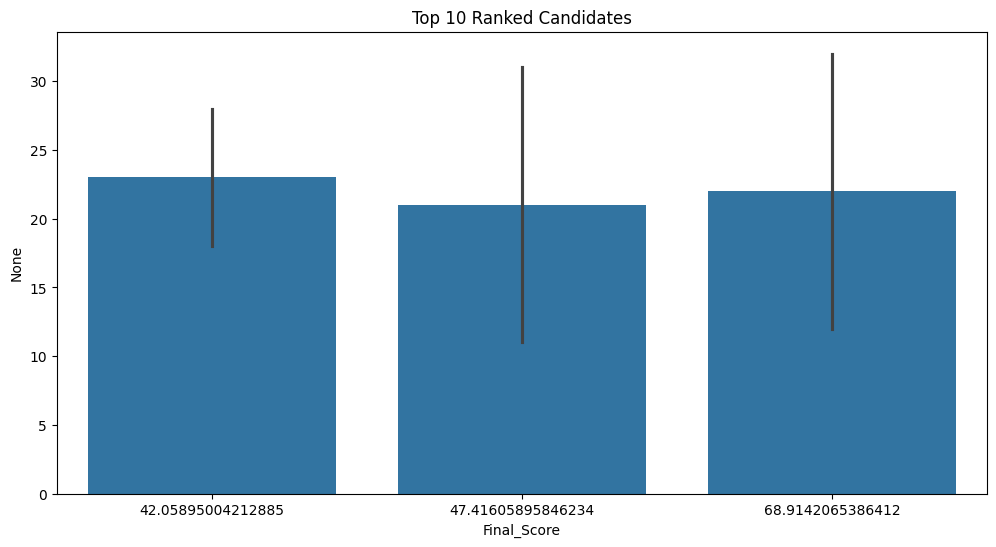

In [55]:
plt.figure(figsize=(12,6))

sns.barplot(

    x=top10["Final_Score"],

    y=top10.index

)

plt.title(
    "Top 10 Ranked Candidates"
)

plt.show()

In [56]:
top10.to_csv(

    "top10_candidates.csv",

    index=False

)

print(
    "Top Candidates Saved"
)

Top Candidates Saved


In [ ]:
# Uncomment only if needed

!pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [58]:
import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.layers import *

from tensorflow.keras.models import Model

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

import joblib

In [59]:
label_encoder = LabelEncoder()

df["Label"] = label_encoder.fit_transform(
    df["Category"]
)

print(
    "Number of classes:",
    len(label_encoder.classes_)
)

Number of classes: 25


In [60]:
label_encoder.classes_

array(['Advocate', 'Arts', 'Automation Testing', 'Blockchain',
       'Business Analyst', 'Civil Engineer', 'Data Science', 'Database',
       'DevOps Engineer', 'DotNet Developer', 'ETL Developer',
       'Electrical Engineering', 'HR', 'Hadoop', 'Health and fitness',
       'Java Developer', 'Mechanical Engineer',
       'Network Security Engineer', 'Operations Manager', 'PMO',
       'Python Developer', 'SAP Developer', 'Sales', 'Testing',
       'Web Designing'], dtype=object)

In [61]:
MAX_WORDS = 15000

tokenizer = Tokenizer(

    num_words=MAX_WORDS,

    oov_token="<OOV>"

)

tokenizer.fit_on_texts(
    df["Clean_Resume"]
)

In [62]:
sequences = tokenizer.texts_to_sequences(
    df["Clean_Resume"]
)

In [63]:
MAX_LEN = 300

In [64]:
X = pad_sequences(

    sequences,

    maxlen=MAX_LEN,

    padding="post",

    truncating="post"

)

X.shape

(962, 300)

In [65]:
y = df["Label"].values

In [66]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [67]:
import numpy as np

In [68]:
def positional_encoding(

    max_len,

    d_model

):

    pe = np.zeros(
        (max_len, d_model)
    )

    for pos in range(max_len):

        for i in range(0, d_model, 2):

            pe[pos, i] = np.sin(

                pos /

                (10000 ** ((2 * i)/d_model))

            )

            if i + 1 < d_model:

                pe[pos, i + 1] = np.cos(

                    pos /

                    (10000 ** ((2 * i)/d_model))

                )

    return pe

In [69]:
PE = positional_encoding(

    max_len=MAX_LEN,

    d_model=128
)

PE.shape

(300, 128)

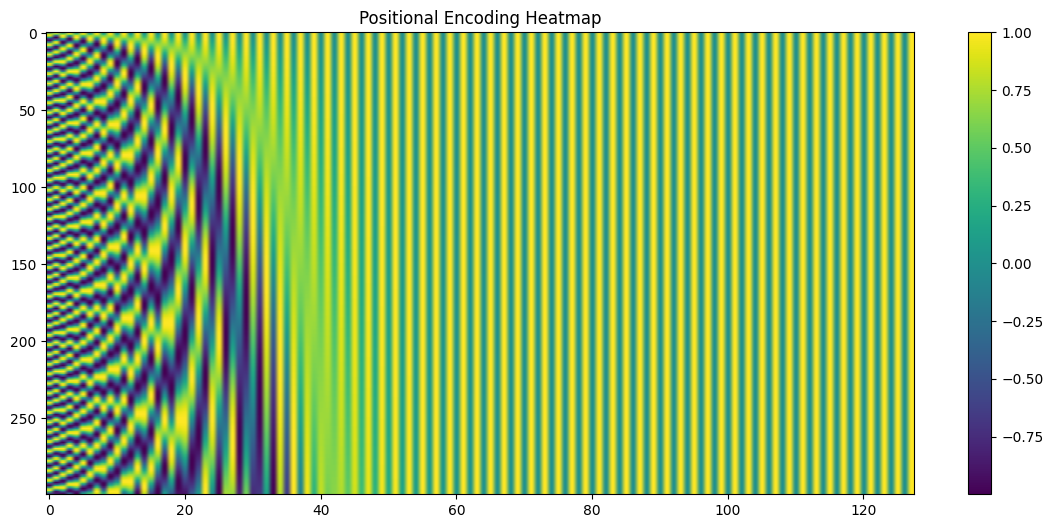

In [70]:
plt.figure(figsize=(14,6))

plt.imshow(

    PE,

    aspect="auto"

)

plt.colorbar()

plt.title(
    "Positional Encoding Heatmap"
)

plt.show()

In [71]:
VOCAB_SIZE = MAX_WORDS

EMBED_DIM = 128

In [72]:
inputs = Input(
    shape=(MAX_LEN,)
)

In [73]:
embedding = Embedding(

    VOCAB_SIZE,

    EMBED_DIM

)(inputs)

In [74]:
attention_output = MultiHeadAttention(

    num_heads=4,

    key_dim=32

)(
    embedding,
    embedding
)

In [75]:
x = Add()(
    [embedding, attention_output]
)

In [76]:
x = LayerNormalization()(x)

In [77]:
x = GlobalAveragePooling1D()(x)

In [78]:
x = Dense(

    256,

    activation="relu"

)(x)

x = Dropout(0.3)(x)

In [79]:
outputs = Dense(

    len(label_encoder.classes_),

    activation="softmax"

)(x)

In [80]:
model = Model(
    inputs,
    outputs
)

In [81]:
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [82]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 300, 128)  │  1,920,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 300, 128)  │     66,048 │ embedding[0][0],  │
│ (MultiHeadAttentio… │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 300, 128)  │          0 │ embedding[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 300, 128)  │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     33,024 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 25)        │      6,425 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,025,753 (7.73 MB)

 Trainable params: 2,025,753 (7.73 MB)

 Non-trainable params: 0 (0.00 B)

In [83]:
history = model.fit(

    X_train,
    y_train,

    validation_data=(

        X_test,
        y_test

    ),

    epochs=10,

    batch_size=32

)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - accuracy: 0.2887 - loss: 2.8084 - val_accuracy: 0.4663 - val_loss: 2.2268
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 0.6242 - loss: 1.7848 - val_accuracy: 0.7772 - val_loss: 1.2249
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - accuracy: 0.7555 - loss: 1.0556 - val_accuracy: 0.8342 - val_loss: 0.6921
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.8531 - loss: 0.6213 - val_accuracy: 0.9378 - val_loss: 0.3109
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.9298 - loss: 0.2946 - val_accuracy: 0.9585 - val_loss: 0.1301
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.9558 - loss: 0.2200 - val_accuracy: 0.9845 - val_loss: 0.0896
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 150ms/step - accuracy: 0.9909 - loss: 0.0553 - val_accuracy: 0.9948 - val_loss: 0.0274
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 156ms/step - accuracy: 0.9974 - loss: 0.0214 - val_accuracy: 0

In [84]:
loss, accuracy = model.evaluate(

    X_test,

    y_test
)

print(
    "Accuracy:",
    accuracy
)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9948 - loss: 0.0123
Accuracy: 0.9948186278343201


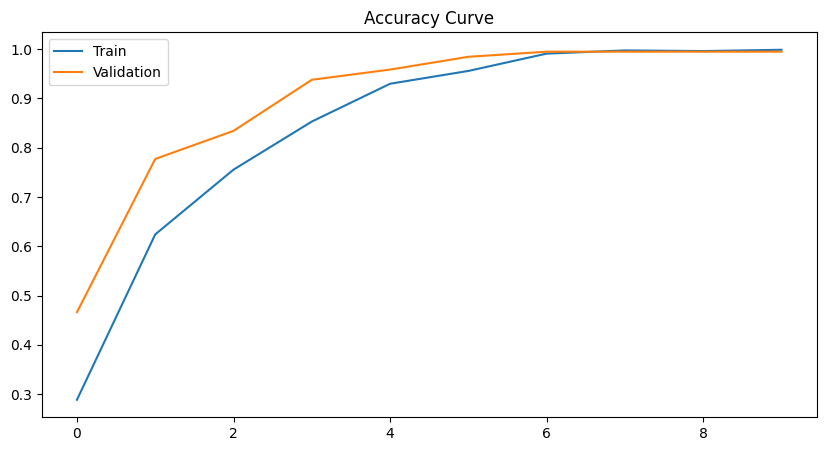

In [85]:
plt.figure(figsize=(10,5))

plt.plot(
    history.history["accuracy"]
)

plt.plot(
    history.history["val_accuracy"]
)

plt.legend([
    "Train",
    "Validation"
])

plt.title(
    "Accuracy Curve"
)

plt.show()

In [86]:
model.save(
    "attention_resume_model.keras"
)

In [87]:
joblib.dump(

    tokenizer,

    "tokenizer.pkl"

)

['tokenizer.pkl']

In [88]:
joblib.dump(

    label_encoder,

    "label_encoder.pkl"

)

['label_encoder.pkl']

In [89]:
joblib.dump(

    tfidf,

    "tfidf.pkl"

)

['tfidf.pkl']

In [90]:
import os

files = [

    "attention_resume_model.keras",

    "tokenizer.pkl",

    "label_encoder.pkl",

    "tfidf.pkl"

]

for file in files:

    print(

        file,

        os.path.exists(file)

    )

attention_resume_model.keras True
tokenizer.pkl True
label_encoder.pkl True
tfidf.pkl True


In [91]:
def explain_match(resume_text, jd_text, top_n=10):

    resume_vec = tfidf.transform([resume_text])

    jd_vec = tfidf.transform([jd_text])

    feature_names = np.array(
        tfidf.get_feature_names_out()
    )

    jd_features = jd_vec.toarray()[0]

    important_idx = np.argsort(
        jd_features
    )[-top_n:]

    important_words = feature_names[
        important_idx
    ]

    return important_words[::-1]

In [92]:
sample_resume = df.iloc[0]["Clean_Resume"]

important_words = explain_match(
    sample_resume,
    job_description
)

important_words

array(['learning', 'looking', 'tensorflow', 'scientist', 'deep', 'data',
       'machine', 'years', 'required', 'python'], dtype=object)

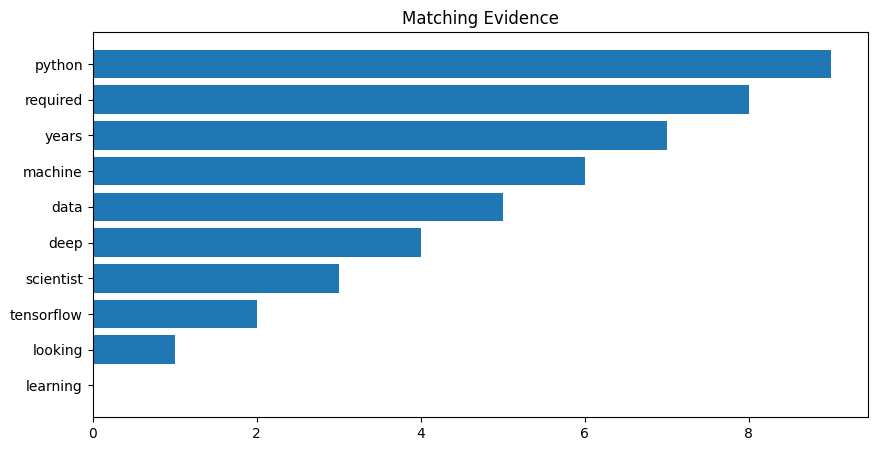

In [93]:
words = explain_match(
    sample_resume,
    job_description
)

plt.figure(figsize=(10,5))

plt.barh(
    words,
    range(len(words))
)

plt.title(
    "Matching Evidence"
)

plt.show()

In [94]:
def generate_explanation(row):

    explanation = f"""

Skill Match: {row['Skill_Match_Percentage']:.2f}%

Experience Match:
{row['Experience_Match_Percentage']:.2f}%

Project Match:
{row['Project_Match_Percentage']:.2f}%

Final Score:
{row['Final_Score']:.2f}

"""

    return explanation

In [95]:
top10["Explanation"] = top10.apply(

    generate_explanation,

    axis=1

)

In [96]:
top10[[
    "Final_Score",
    "Explanation"
]].head()

,Final_Score,Explanation
37,68.914207,\n\nSkill Match: 100.00%\n\nExperience Match:\...
17,68.914207,\n\nSkill Match: 100.00%\n\nExperience Match:\...
27,68.914207,\n\nSkill Match: 100.00%\n\nExperience Match:\...
7,68.914207,\n\nSkill Match: 100.00%\n\nExperience Match:\...
36,47.416059,\n\nSkill Match: 57.14%\n\nExperience Match:\n...


In [97]:
top10.to_csv(

    "hiring_report.csv",

    index=False

)

print(
    "Hiring Report Exported"
)

Hiring Report Exported


In [98]:
plt.figure(figsize=(12,5))

plt.imshow(
    PE,
    aspect="auto"
)

plt.colorbar()

plt.title(
    "Positional Encoding Heatmap"
)

plt.savefig(
    "positional_heatmap.png"
)

plt.close()

In [99]:
plt.figure(figsize=(10,5))

plt.bar(

    range(len(top10)),

    top10["Final_Score"]

)

plt.title(
    "Top Candidate Scores"
)

plt.savefig(
    "candidate_scores.png"
)

plt.close()

In [100]:
import os

required_files = [

    "attention_resume_model.keras",

    "tokenizer.pkl",

    "label_encoder.pkl",

    "tfidf.pkl",

    "hiring_report.csv",

    "positional_heatmap.png",

    "candidate_scores.png"

]

for file in required_files:

    print(

        file,

        os.path.exists(file)

    )

attention_resume_model.keras True
tokenizer.pkl True
label_encoder.pkl True
tfidf.pkl True
hiring_report.csv True
positional_heatmap.png True
candidate_scores.png True


In [101]:
model.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9948 - loss: 0.0123


[0.01226292084902525, 0.9948186278343201]